# File for training the GNN models
This file will be used to train the different models used in the project

In [51]:
import os
# if os is windows, use the following command to install the required packages
if os.name == 'nt':
    !pip install pyg_lib torch_scatter torch_sparse torch_cluster -f https://data.pyg.org/whl/torch-2.11.0+cu130.html
else:
    !pip install pyg_lib torch_scatter torch_sparse torch_cluster -f https://data.pyg.org/whl/torch-2.11.0+cpu.html

Looking in links: https://data.pyg.org/whl/torch-2.11.0+cpu.html


## The Dataset and dataloader 
below the dataset and data loader will be prepared, the flag column will be used as target column since this column indicates whether it is fraud. Only the columns containing numbers will be used since those are easiest to train on, and will suffice for the further research

First we split the data 

In [52]:
# !pip install torch_geometric
from torch_geometric.data import Data
import pandas as pd
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

data = pd.read_csv("transaction_dataset.csv")

target_col = "FLAG"
if target_col not in data.columns:
    raise ValueError("Expected target column 'FLAG' in transaction_dataset.csv")

# Drop obvious leakage / identifier columns if present.
leakage_cols = ["Unnamed: 0", "Index"]
feature_df = data.drop(columns=[target_col] + leakage_cols, errors="ignore")

# Keep only numeric features for the GCN input.
num_df = feature_df.select_dtypes(include="number")
if num_df.shape[1] == 0:
    X = torch.zeros((len(data), 1), dtype=torch.float)
else:
    y_array = data[target_col].to_numpy()
    all_idx = np.arange(len(data))
    train_idx_np, test_idx_np = train_test_split(
        all_idx,
        test_size=0.2,
        random_state=42,
        stratify=y_array,
    )

    # Fit preprocessing on train rows only to avoid test leakage.
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    train_features = imputer.fit_transform(num_df.iloc[train_idx_np])
    train_features = scaler.fit_transform(train_features)
    all_features = scaler.transform(imputer.transform(num_df))

    X = torch.tensor(all_features, dtype=torch.float)

    train_idx = torch.tensor(train_idx_np, dtype=torch.long)
    test_idx = torch.tensor(test_idx_np, dtype=torch.long)

# Build a simple valid edge_index (chain graph: 0->1->2->...)
num_nodes = X.size(0)
if num_nodes >= 2:
    src = torch.arange(0, num_nodes - 1, dtype=torch.long)
    dst = torch.arange(1, num_nodes, dtype=torch.long)
    edge_index = torch.stack([src, dst], dim=0)
else:
    edge_index = torch.empty((2, 0), dtype=torch.long)

# Add labels
y = torch.tensor(data[target_col].values, dtype=torch.long)

# Build graph data object
train_data = Data(x=X, edge_index=edge_index, y=y)

# Train/test split masks
num_nodes = train_data.num_nodes
train_data.train_mask = torch.zeros(num_nodes, dtype=torch.bool)
train_data.test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_data.train_mask[train_idx] = True
train_data.test_mask[test_idx] = True

train_pos = int(train_data.y[train_data.train_mask].sum().item())
train_total = int(train_data.train_mask.sum().item())
test_pos = int(train_data.y[train_data.test_mask].sum().item())
test_total = int(train_data.test_mask.sum().item())
majority_baseline = max(train_total - train_pos, train_pos) / train_total if train_total > 0 else 0

print(f"Nodes: {num_nodes}, Features: {X.size(1)}, Classes: {int(y.max().item()) + 1}")
print(f"Train class-1 rate: {train_pos / train_total:.4f}, Test class-1 rate: {test_pos / test_total:.4f}")
print(f"Majority-class baseline accuracy on train split: {majority_baseline:.4f}")
print(f"Any NaN in X: {torch.isnan(X).any().item()}, Any Inf in X: {torch.isinf(X).any().item()}")
print(f"duplicate nodes in test and train: {(train_data.train_mask & train_data.test_mask).any().item()}")



Nodes: 9841, Features: 45, Classes: 2
Train class-1 rate: 0.2214, Test class-1 rate: 0.2214
Majority-class baseline accuracy on train split: 0.7786
Any NaN in X: False, Any Inf in X: False
duplicate nodes in test and train: False


## Defining the models 

Below the models will be definined, the selected models for now are the Graph Convolotion Network (GCN), Graph Attention Network (GAT) and Graph Isomorpishm Network (GIN).

In [53]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.nn import GATConv
from torch_geometric.nn import GINConv


class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x  # raw logits, no log_softmax

num_classes = int(train_data.y.max().item()) + 1
model_GCN = GCN(in_channels=X.size(1), hidden_channels=16, out_channels=num_classes)
optimizer = torch.optim.Adam(model_GCN.parameters(), lr=0.005, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=4, dropout=0.5):
        super().__init__()
        self.conv1 = GATConv(
            in_channels,
            hidden_channels,
            heads=heads,
            dropout=dropout
        )
        self.conv2 = GATConv(
            hidden_channels * heads,
            out_channels,
            heads=1,
            concat=False,      # typical for the final GAT layer
            dropout=dropout
        )
        self.dropout = dropout

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x  # logits
num_classes = int(train_data.y.max().item()) + 1
gat_model = GAT(
    in_channels=train_data.x.size(1),
    hidden_channels=16,
    out_channels=num_classes,
    heads=4,
    dropout=0.5,
)
gat_optimizer = torch.optim.Adam(gat_model.parameters(), lr=0.005, weight_decay=5e-4)
gat_criterion = torch.nn.CrossEntropyLoss()


class GIN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GINConv(
            torch.nn.Sequential(
                torch.nn.Linear(in_channels, hidden_channels),
                torch.nn.ReLU(),
                torch.nn.Linear(hidden_channels, hidden_channels)
            )
        )
        self.conv2 = GINConv(
            torch.nn.Sequential(
                torch.nn.Linear(hidden_channels, hidden_channels),
                torch.nn.ReLU(),
                torch.nn.Linear(hidden_channels, out_channels)
            )
        )

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x  # logits
gin_model = GIN(
    in_channels=train_data.x.size(1),
    hidden_channels=16,
    out_channels=num_classes,
)
gin_optimizer = torch.optim.Adam(gin_model.parameters(), lr=0.005, weight_decay=5e-4)
gin_criterion = torch.nn.CrossEntropyLoss()



## Training the models
Below all used models will be trained 

In [54]:

def train(model, optimizer, criterion, data, model_name="Model", epochs=200, print_every=20):
    """
    Generic training loop for a GNN model. Trains for variable amount of epochs and prints loss every variable epochs.
    """

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        out = model(data)  # [num_nodes, num_classes]
        logits = out[data.train_mask]
        target = data.y[data.train_mask]
        loss = criterion(logits, target)

        if not torch.isfinite(loss):
            raise RuntimeError(f"{model_name} loss became non-finite. Check feature preprocessing and labels.")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()

        if (epoch + 1) % print_every == 0:
            print(f"{model_name} Epoch {epoch+1}, Loss: {loss.item():.4f}")

model_GCN.train()
train(model_GCN, optimizer, criterion, train_data, model_name="GCN", epochs
=200, print_every=20)
gat_model.train()
train(gat_model, gat_optimizer, gat_criterion, train_data, model_name="GAT", epochs=200, print_every=20)
gin_model.train()
train(gin_model, gin_optimizer, gin_criterion, train_data, model_name="GIN", epochs=200, print_every=20)




GCN Epoch 20, Loss: 0.4881
GCN Epoch 40, Loss: 0.4080
GCN Epoch 60, Loss: 0.3531
GCN Epoch 80, Loss: 0.3324
GCN Epoch 100, Loss: 0.3079
GCN Epoch 120, Loss: 0.2898
GCN Epoch 140, Loss: 0.2752
GCN Epoch 160, Loss: 0.2579
GCN Epoch 180, Loss: 0.2460
GCN Epoch 200, Loss: 0.2368
GAT Epoch 20, Loss: 0.4804
GAT Epoch 40, Loss: 0.4459
GAT Epoch 60, Loss: 0.4223
GAT Epoch 80, Loss: 0.4126
GAT Epoch 100, Loss: 0.3907
GAT Epoch 120, Loss: 0.3777
GAT Epoch 140, Loss: 0.3658
GAT Epoch 160, Loss: 0.3535
GAT Epoch 180, Loss: 0.3430
GAT Epoch 200, Loss: 0.3302
GIN Epoch 20, Loss: 0.4961
GIN Epoch 40, Loss: 0.3614
GIN Epoch 60, Loss: 0.2960
GIN Epoch 80, Loss: 0.2269
GIN Epoch 100, Loss: 0.1696
GIN Epoch 120, Loss: 0.1134
GIN Epoch 140, Loss: 0.0859
GIN Epoch 160, Loss: 0.0654
GIN Epoch 180, Loss: 0.0474
GIN Epoch 200, Loss: 0.0414


## Model eval
Below the models will be evaluated 

In [55]:
def evaluate(model, data, model_name="Model"):
    model.eval()
    with torch.no_grad():
        out = model(data)
        test_logits = out[data.test_mask]
        test_target = data.y[data.test_mask]
        pred = test_logits.argmax(dim=1)
        correct = (pred == test_target).sum().item()
        total = test_target.numel()
        accuracy = correct / total if total > 0 else 0
        print(f"{model_name} Test Accuracy: {accuracy:.4f}")
        if total > 0:
            probs = torch.softmax(test_logits, dim=1)[:, 1]  # only valid if num_classes >= 2
            print(f"{model_name} Mean predicted probability for class 1: {probs.mean().item():.4f}")


evaluate(model_GCN, train_data, model_name="GCN")
evaluate(gat_model, train_data, model_name="GAT")
evaluate(gin_model, train_data, model_name="GIN")

GCN Test Accuracy: 0.9274
GCN Mean predicted probability for class 1: 0.2147
GAT Test Accuracy: 0.9391
GAT Mean predicted probability for class 1: 0.1915
GIN Test Accuracy: 0.9873
GIN Mean predicted probability for class 1: 0.2157


# Test for data leakage 
Below the data will be tested on leakage to ensure that teh result is valid

In [56]:
# to test for leaks in data labels, we can shuffle the labels and see if the GIN can still learn something. If it can, then there is likely some leakage in the data that allows the model to learn even with random labels.
y_shuffled = y.clone()
perm = torch.randperm(len(y_shuffled))
y_shuffled = y_shuffled[perm]

train_data_shuffled = Data(x=X, edge_index=edge_index, y=y_shuffled)
train_data_shuffled.train_mask = train_data.train_mask
train_data_shuffled.test_mask = train_data.test_mask


train(model_GCN, optimizer, criterion, train_data_shuffled, model_name="GCN with shuffled labels", epochs=200, print_every=20)
train(gat_model, gat_optimizer, gat_criterion, train_data_shuffled, model_name="GAT with shuffled labels", epochs=200, print_every=20)
train(gin_model, gin_optimizer, gin_criterion, train_data_shuffled, model_name="GIN with shuffled labels", epochs=200, print_every=20)


evaluate(model_GCN, train_data_shuffled, model_name="GCN with shuffled labels")
evaluate(gat_model, train_data_shuffled, model_name="GAT with shuffled labels")
evaluate(gin_model, train_data_shuffled, model_name="GIN with shuffled labels")

GCN with shuffled labels Epoch 20, Loss: 0.6244
GCN with shuffled labels Epoch 40, Loss: 0.5437
GCN with shuffled labels Epoch 60, Loss: 0.5354
GCN with shuffled labels Epoch 80, Loss: 0.5306
GCN with shuffled labels Epoch 100, Loss: 0.5298
GCN with shuffled labels Epoch 120, Loss: 0.5280
GCN with shuffled labels Epoch 140, Loss: 0.5279
GCN with shuffled labels Epoch 160, Loss: 0.5255
GCN with shuffled labels Epoch 180, Loss: 0.5244
GCN with shuffled labels Epoch 200, Loss: 0.5260
GAT with shuffled labels Epoch 20, Loss: 0.5788
GAT with shuffled labels Epoch 40, Loss: 0.5374
GAT with shuffled labels Epoch 60, Loss: 0.5299
GAT with shuffled labels Epoch 80, Loss: 0.5284
GAT with shuffled labels Epoch 100, Loss: 0.5255
GAT with shuffled labels Epoch 120, Loss: 0.5260
GAT with shuffled labels Epoch 140, Loss: 0.5258
GAT with shuffled labels Epoch 160, Loss: 0.5255
GAT with shuffled labels Epoch 180, Loss: 0.5250
GAT with shuffled labels Epoch 200, Loss: 0.5247
GIN with shuffled labels Epo

## making plots
Making a set of plots to better show the fiffetence in model

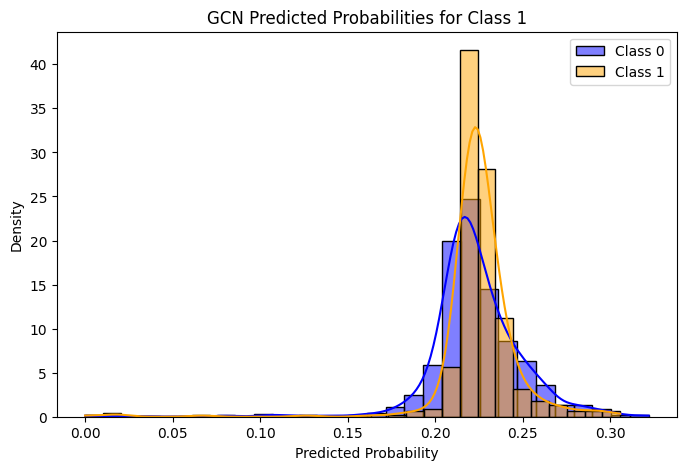

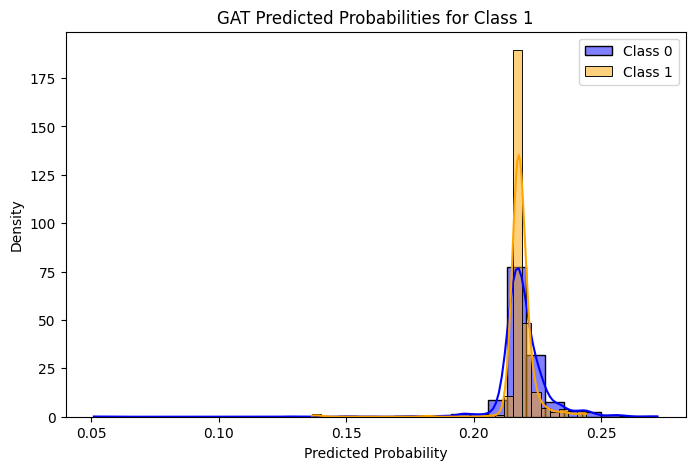

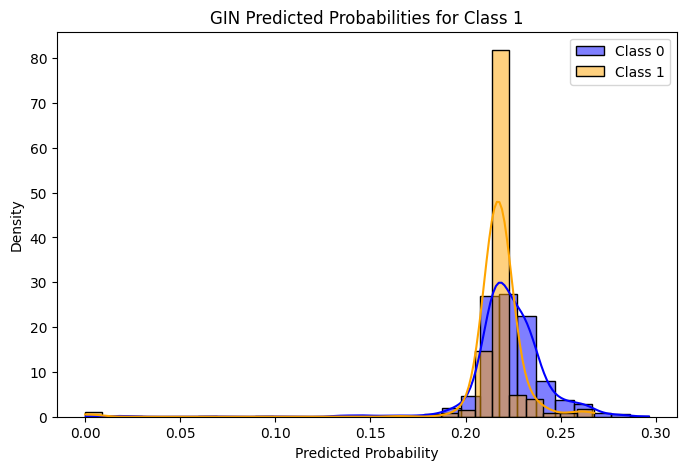

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_predictions(model, data, model_name="Model"):
    model.eval()
    with torch.no_grad():
        out = model(data)
        test_logits = out[data.test_mask]
        test_target = data.y[data.test_mask]
        probs = torch.softmax(test_logits, dim=1)[:, 1].cpu().numpy()  # probability of class 1
        target_np = test_target.cpu().numpy()

    plt.figure(figsize=(8, 5))
    sns.histplot(probs[target_np == 0], color="blue", label="Class 0", kde=True, stat="density", bins=30)
    sns.histplot(probs[target_np == 1], color="orange", label="Class 1", kde=True, stat="density", bins=30)
    plt.title(f"{model_name} Predicted Probabilities for Class 1")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

plot_predictions(model_GCN, train_data, model_name="GCN")
plot_predictions(gat_model, train_data, model_name="GAT")
plot_predictions(gin_model, train_data, model_name="GIN")